# BTC Volatility Transformer - Part 2: Model Training

**Prerequisites**: Run Part 1 notebook first to generate the data files.

**This Notebook**: Build and train a transformer model to predict 24-hour forward volatility.

---

## Learning Objectives

By the end of this notebook, you'll understand:
- How to create sequence datasets for time series transformers
- The connection between your Week 3 character-level transformer and this volatility model
- How to adapt transformer architecture for regression (not classification)
- Training loops with validation and early stopping
- Comparing against baseline models (EWMA, naive)

---

## Connection to Week 3

| Week 3 (Character LM) | This Notebook (Volatility) |
|----------------------|---------------------------|
| Input: character IDs | Input: feature vectors |
| `nn.Embedding` | `nn.Linear` projection |
| Output: vocab probabilities | Output: single volatility value |
| Loss: CrossEntropy | Loss: MSE |
| **Same**: MultiHeadAttention, TransformerBlock, PositionalEncoding |

---
## Section 1: Setup

In [ ]:
# =============================================================================
# STEP 1.1: Mount Google Drive and set paths
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

# Path to your saved data from Part 1
DATA_DIR = '/content/drive/MyDrive/btc_volatility_project'

print(f"Data directory: {DATA_DIR}")

In [ ]:
# =============================================================================
# STEP 1.2: Imports
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# For progress bars
from tqdm import tqdm

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [ ]:
# =============================================================================
# STEP 1.3: Load data from Part 1 (via btc_volatility_01_data_pipeline.ipynb)
# =============================================================================

# Load the CSV files
train_df = pd.read_csv(f'{DATA_DIR}/btc_train.csv')
val_df = pd.read_csv(f'{DATA_DIR}/btc_val.csv')
test_df = pd.read_csv(f'{DATA_DIR}/btc_test.csv')

# Load metadata
with open(f'{DATA_DIR}/btc_metadata.json', 'r') as f:
    metadata = json.load(f)

FEATURE_COLS = metadata['feature_columns']
TARGET_COL = metadata['target_column']

print(f"✓ Data loaded from {DATA_DIR}")
print(f"\nDataset sizes:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Val:   {len(val_df):,} samples")
print(f"  Test:  {len(test_df):,} samples")
print(f"\nFeatures: {len(FEATURE_COLS)}")
print(f"Target: {TARGET_COL}")

---
## Section 2: Create Sequence Datasets

### 🎓 Teaching Moment: Sequences for Time Series

Transformers process **sequences**. For time series, we create overlapping windows:

```
Data: [h0, h1, h2, h3, h4, h5, h6, h7, h8, ...]

With seq_len=4:
  Sequence 0: [h0, h1, h2, h3] → predict target at h3
  Sequence 1: [h1, h2, h3, h4] → predict target at h4
  Sequence 2: [h2, h3, h4, h5] → predict target at h5
  ...
```

The model sees `seq_len` hours of history and predicts volatility for the last timestep.

**Why overlapping?**
- Maximizes training data (we use every hour as a prediction point)
- Each sequence still respects causality (only uses past data)

In [ ]:
# =============================================================================
# STEP 2.1: Define the Dataset class
# =============================================================================

class VolatilitySequenceDataset(Dataset):
    """
    Creates sequences of features for transformer input.

    🎓 Teaching Moment: PyTorch Dataset

    A Dataset needs two methods:
      - __len__: returns total number of samples
      - __getitem__: returns one sample (features, target) given an index

    The DataLoader then handles batching, shuffling, etc.
    """

    def __init__(self, df, feature_cols, target_col, seq_len):
        """
        Parameters:
        -----------
        df : DataFrame with features and target
        feature_cols : list of column names to use as features
        target_col : name of target column
        seq_len : number of timesteps in each sequence
        """
        self.seq_len = seq_len

        # Convert to numpy arrays for faster indexing
        self.features = df[feature_cols].values.astype(np.float32)
        self.targets = df[target_col].values.astype(np.float32)

        # Number of valid sequences
        # We need seq_len points, so first valid target is at index seq_len-1
        self.n_sequences = len(df) - seq_len + 1

    def __len__(self):
        return self.n_sequences

    def __getitem__(self, idx):
        """
        Returns:
        --------
        X : tensor of shape (seq_len, num_features)
        y : scalar target (volatility at the last timestep)
        """
        # Get sequence of features
        X = self.features[idx : idx + self.seq_len]

        # Target is at the last timestep of the sequence
        y = self.targets[idx + self.seq_len - 1]

        return torch.tensor(X), torch.tensor(y)

print("✓ VolatilitySequenceDataset class defined")

In [ ]:
# =============================================================================
# STEP 2.2: Create datasets and dataloaders
# =============================================================================

# Hyperparameters
SEQ_LEN = 64       # 64 hours ≈ 2.7 days of history
BATCH_SIZE = 128   # Number of sequences per batch

# Create datasets
train_dataset = VolatilitySequenceDataset(train_df, FEATURE_COLS, TARGET_COL, SEQ_LEN)
val_dataset = VolatilitySequenceDataset(val_df, FEATURE_COLS, TARGET_COL, SEQ_LEN)
test_dataset = VolatilitySequenceDataset(test_df, FEATURE_COLS, TARGET_COL, SEQ_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Sequence length: {SEQ_LEN} hours ({SEQ_LEN/24:.1f} days)")
print(f"Batch size: {BATCH_SIZE}")
print(f"\nDataset sizes (sequences):")
print(f"  Train: {len(train_dataset):,}")
print(f"  Val:   {len(val_dataset):,}")
print(f"  Test:  {len(test_dataset):,}")
print(f"\nBatches per epoch: {len(train_loader):,}")

In [ ]:
# =============================================================================
# STEP 2.3: Verify a sample batch
# =============================================================================

# Get one batch to check shapes
X_batch, y_batch = next(iter(train_loader))

print("Sample batch shapes:")
print(f"  X (features): {X_batch.shape}  → (batch_size, seq_len, num_features)")
print(f"  y (targets):  {y_batch.shape}  → (batch_size,)")
print(f"\nFeature values range: [{X_batch.min():.2f}, {X_batch.max():.2f}]")
print(f"Target values range:  [{y_batch.min():.4f}, {y_batch.max():.4f}]")

---
## Section 3: Transformer Architecture

### 🎓 Teaching Moment: From Week 3 to Volatility

Your Week 3 transformer had these components:

```
Character LM:
  Input IDs → Embedding → PositionalEncoding → TransformerBlocks → Linear → Softmax
              (discrete)                                          (vocab_size outputs)

Volatility Model:
  Features → Linear Projection → PositionalEncoding → TransformerBlocks → Pooling → Linear → Output
             (continuous)                                                            (1 output)
```

The core blocks (attention, FFN, layer norm) are **identical**!

Key differences:
1. **Input**: Continuous features instead of discrete token IDs
2. **Output**: Single regression value instead of vocabulary distribution
3. **Pooling**: We need to aggregate the sequence into one prediction

In [ ]:
# =============================================================================
# STEP 3.1: Scaled Dot-Product Attention
# =============================================================================

# 🎓 This is IDENTICAL to your Week 3 implementation!
#
# Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V
#
# The scaling by sqrt(d_k) prevents dot products from getting too large,
# which would push softmax into regions with tiny gradients.

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Compute scaled dot-product attention.

    Parameters:
    -----------
    Q : tensor of shape (batch, heads, seq_len, d_k)
    K : tensor of shape (batch, heads, seq_len, d_k)
    V : tensor of shape (batch, heads, seq_len, d_v)
    mask : optional tensor for masking future positions

    Returns:
    --------
    output : tensor of shape (batch, heads, seq_len, d_v)
    attention_weights : tensor of shape (batch, heads, seq_len, seq_len)
    """
    d_k = Q.size(-1)

    # Compute attention scores: QK^T / sqrt(d_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)

    # Apply mask if provided (for causal attention)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # Softmax to get attention weights
    attention_weights = torch.softmax(scores, dim=-1)

    # Apply attention to values
    output = torch.matmul(attention_weights, V)

    return output, attention_weights

print("✓ scaled_dot_product_attention defined")

In [ ]:
# =============================================================================
# STEP 3.2: Multi-Head Attention
# =============================================================================

# 🎓 Also identical to Week 3!
#
# Multi-head attention runs multiple attention operations in parallel,
# each with different learned projections. This allows the model to
# attend to information from different representation subspaces.

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention mechanism.

    Parameters:
    -----------
    d_model : int, dimension of model (embedding size)
    num_heads : int, number of attention heads
    """

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head

        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Output projection
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        """
        Parameters:
        -----------
        x : tensor of shape (batch, seq_len, d_model)
        mask : optional attention mask

        Returns:
        --------
        output : tensor of shape (batch, seq_len, d_model)
        """
        batch_size, seq_len, _ = x.shape

        # Project to Q, K, V
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)
        V = self.W_v(x)

        # Reshape for multi-head: (batch, seq_len, d_model) → (batch, num_heads, seq_len, d_k)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # Apply attention
        attn_output, _ = scaled_dot_product_attention(Q, K, V, mask)

        # Concatenate heads: (batch, num_heads, seq_len, d_k) → (batch, seq_len, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        # Final projection
        output = self.W_o(attn_output)

        return output

print("✓ MultiHeadAttention defined")

In [ ]:
# =============================================================================
# STEP 3.3: Position-wise Feed-Forward Network
# =============================================================================

# 🎓 Same as Week 3!
#
# The FFN applies the same transformation to each position independently.
# It typically expands the dimension (d_model → d_ff), applies non-linearity,
# then contracts back (d_ff → d_model).

class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network.

    FFN(x) = max(0, xW_1 + b_1)W_2 + b_2
    """

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()  # GELU often works better than ReLU

    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))

print("✓ FeedForward defined")

In [ ]:
# =============================================================================
# STEP 3.4: Transformer Block (Pre-LN variant)
# =============================================================================

# 🎓 Same structure as Week 3!
#
# Pre-LN (Layer Norm before attention/FFN) is more stable than Post-LN.
# Structure:
#   x → LayerNorm → Attention → + residual → LayerNorm → FFN → + residual → output

class TransformerBlock(nn.Module):
    """
    Single Transformer block with Pre-LN structure.
    """

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Pre-LN: normalize before attention
        attn_out = self.attention(self.norm1(x), mask)
        x = x + self.dropout(attn_out)  # Residual connection

        # Pre-LN: normalize before FFN
        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)  # Residual connection

        return x

print("✓ TransformerBlock defined")

In [ ]:
# =============================================================================
# STEP 3.5: Positional Encoding
# =============================================================================

# 🎓 Same as Week 3!
#
# Transformers have no inherent notion of position (unlike RNNs).
# Positional encoding adds position information via sinusoidal patterns.
#
# PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
# PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding.
    """

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)  # Even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # Odd indices

        pe = pe.unsqueeze(0)  # Add batch dimension: (1, max_len, d_model)
        self.register_buffer('pe', pe)  # Not a learnable parameter

    def forward(self, x):
        """
        x : tensor of shape (batch, seq_len, d_model)
        """
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)

print("✓ PositionalEncoding defined")

In [ ]:
import torch.nn as nn

# =============================================================================
# STEP 3.6: Complete Volatility Transformer Model
# =============================================================================

# 🎓 Teaching Moment: Key Differences from Character LM
#
# 1. INPUT PROJECTION:
#    - Character LM: nn.Embedding(vocab_size, d_model) - lookup table
#    - Volatility:   nn.Linear(num_features, d_model) - linear projection
#
# 2. OUTPUT:
#    - Character LM: Linear → Softmax over vocabulary (classification)
#    - Volatility:   Pooling → Linear → single value (regression)
#
# 3. POOLING:
#    - Character LM predicts at each position (next character)
#    - Volatility predicts ONE value for the whole sequence
#    - We use the LAST position's output (it has seen all history)

class VolatilityTransformer(nn.Module):
    """
    Transformer for volatility prediction.

    Architecture:
    Input (batch, seq_len, num_features)
      → Linear projection to d_model
      → Positional encoding
      → N × Transformer blocks
      → Take last position (pooling)
      → Linear to 1 output
    Output (batch, 1)
    """

    def __init__(self, num_features, d_model=128, num_heads=4, num_layers=4,
                 d_ff=512, dropout=0.1, max_len=5000):
        super().__init__()

        self.d_model = d_model

        # Input projection: features → d_model
        # (This replaces nn.Embedding from character LM)
        self.input_projection = nn.Linear(num_features, d_model)

        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

        # Stack of transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        # Final layer norm (Pre-LN style requires this at the end)
        self.final_norm = nn.LayerNorm(d_model)

        # Output projection: d_model → 1 (volatility prediction)
        self.output_projection = nn.Linear(d_model, 1)

        # Add a Softplus activation to ensure non-negative volatility predictions
        self.output_activation = nn.Softplus()

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize weights using Xavier/Glorot initialization."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x, mask=None):
        """
        Parameters:
        -----------
        x : tensor of shape (batch, seq_len, num_features)
        mask : optional attention mask

        Returns:
        --------
        output : tensor of shape (batch,) - predicted volatility
        """
        # Project input features to model dimension
        x = self.input_projection(x)  # (batch, seq_len, d_model)

        # Add positional encoding
        x = self.pos_encoding(x)

        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x, mask)

        # Final layer norm
        x = self.final_norm(x)

        # Pooling: take the last position's output
        # (It has "seen" all previous positions via attention)
        x = x[:, -1, :]  # (batch, d_model)

        # Project to single output
        output = self.output_projection(x)  # (batch, 1)

        # Apply activation to ensure non-negative output
        output = self.output_activation(output)

        return output.squeeze(-1)  # (batch,)

In [ ]:
# =============================================================================
# STEP 3.7: Instantiate the model
# =============================================================================

# Model hyperparameters
NUM_FEATURES = len(FEATURE_COLS)
D_MODEL = 128       # Model dimension (was 64 in your SPY model)
NUM_HEADS = 4       # Number of attention heads
NUM_LAYERS = 4      # Number of transformer blocks (was 2 in SPY)
D_FF = 512          # Feed-forward hidden dimension
DROPOUT = 0.1       # Dropout rate

# Create model
model = VolatilityTransformer(
    num_features=NUM_FEATURES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("VOLATILITY TRANSFORMER MODEL")
print("=" * 50)
print(f"\nArchitecture:")
print(f"  Input features:    {NUM_FEATURES}")
print(f"  Model dimension:   {D_MODEL}")
print(f"  Attention heads:   {NUM_HEADS}")
print(f"  Transformer layers:{NUM_LAYERS}")
print(f"  FF dimension:      {D_FF}")
print(f"  Dropout:           {DROPOUT}")
print(f"\nTotal parameters:    {num_params:,}")
print(f"Trainable parameters:{num_trainable:,}")

In [ ]:
# =============================================================================
# STEP 3.8: Verify model with a test forward pass
# =============================================================================

# Test forward pass
with torch.no_grad():
    X_test = X_batch.to(device)
    y_pred = model(X_test)

print(f"Test forward pass:")
print(f"  Input shape:  {X_test.shape}")
print(f"  Output shape: {y_pred.shape}")
print(f"  Output range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
print("\n✓ Model forward pass successful!")

---
## Section 4: Training Setup

### 🎓 Teaching Moment: Regression Loss

For regression (predicting a continuous value), we use **MSE Loss**:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

This is different from your character LM which used **CrossEntropyLoss** for classification.

For evaluation, we also track **RMSE** (Root MSE) and **MAE** (Mean Absolute Error) since they're more interpretable.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# For progress bars
from tqdm import tqdm

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
# =============================================================================
# STEP 4.1: Define loss and optimizer
# =============================================================================

# Loss function: MSE for regression
criterion = nn.MSELoss()

# Optimizer: AdamW (Adam with proper weight decay)
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler: reduce LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      # Minimize validation loss
    factor=0.5,      # Reduce LR by half
    patience=5       # Wait 5 epochs before reducing
)

print(f"Loss function: MSELoss")
print(f"Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)")

In [ ]:
# =============================================================================
# STEP 4.2: Training and evaluation functions
# =============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    num_batches = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


def evaluate(model, loader, criterion, device):
    """Evaluate on a dataset."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            total_loss += loss.item() * len(y_batch)
            all_preds.extend(y_pred.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Calculate metrics
    rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
    mae = np.mean(np.abs(all_preds - all_targets))

    return avg_loss, rmse, mae, all_preds, all_targets

print("✓ Training functions defined")

---
## Section 5: Training Loop

### 🎓 Teaching Moment: Early Stopping

With ~27,000 training samples, overfitting is a real risk. Early stopping helps:

1. Track validation loss each epoch
2. Save the best model (lowest val loss)
3. If val loss doesn't improve for N epochs, stop training

This prevents the model from memorizing the training data.

In [17]:
# =============================================================================
# STEP 5.1: Training loop with early stopping
# =============================================================================

NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

# Track history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_rmse': [],
    'val_mae': [],
    'lr': []
}

# Early stopping variables
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
best_model_state = None

print("=" * 60)
print("TRAINING")
print("=" * 60)
print(f"Epochs: {NUM_EPOCHS} (early stopping patience: {EARLY_STOP_PATIENCE})")
print()

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate
    val_loss, val_rmse, val_mae, _, _ = evaluate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_rmse'].append(val_rmse)
    history['val_mae'].append(val_mae)
    history['lr'].append(current_lr)

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        improved = "✓ (best)"
    else:
        patience_counter += 1
        improved = ""

    # Print progress
    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f} | "
          f"Val RMSE: {val_rmse*100:.3f}% | "
          f"LR: {current_lr:.2e} {improved}")

    # Early stopping check
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered! No improvement for {EARLY_STOP_PATIENCE} epochs.")
        break

# Restore best model
model.load_state_dict(best_model_state)
print(f"\n✓ Restored best model from epoch {best_epoch + 1}")

TRAINING
Epochs: 50 (early stopping patience: 10)

Epoch   1/50 | Train Loss: 0.004387 | Val Loss: 0.000027 | Val RMSE: 0.520% | LR: 1.00e-04 ✓ (best)
Epoch   2/50 | Train Loss: 0.000064 | Val Loss: 0.000027 | Val RMSE: 0.516% | LR: 1.00e-04 ✓ (best)
Epoch   3/50 | Train Loss: 0.000043 | Val Loss: 0.000026 | Val RMSE: 0.507% | LR: 1.00e-04 ✓ (best)
Epoch   4/50 | Train Loss: 0.000037 | Val Loss: 0.000021 | Val RMSE: 0.454% | LR: 1.00e-04 ✓ (best)
Epoch   5/50 | Train Loss: 0.000026 | Val Loss: 0.000007 | Val RMSE: 0.268% | LR: 1.00e-04 ✓ (best)
Epoch   6/50 | Train Loss: 0.000016 | Val Loss: 0.000006 | Val RMSE: 0.249% | LR: 1.00e-04 ✓ (best)
Epoch   7/50 | Train Loss: 0.000015 | Val Loss: 0.000006 | Val RMSE: 0.240% | LR: 1.00e-04 ✓ (best)
Epoch   8/50 | Train Loss: 0.000013 | Val Loss: 0.000006 | Val RMSE: 0.238% | LR: 1.00e-04 ✓ (best)
Epoch   9/50 | Train Loss: 0.000013 | Val Loss: 0.000005 | Val RMSE: 0.228% | LR: 1.00e-04 ✓ (best)
Epoch  10/50 | Train Loss: 0.000011 | Val Loss: 0

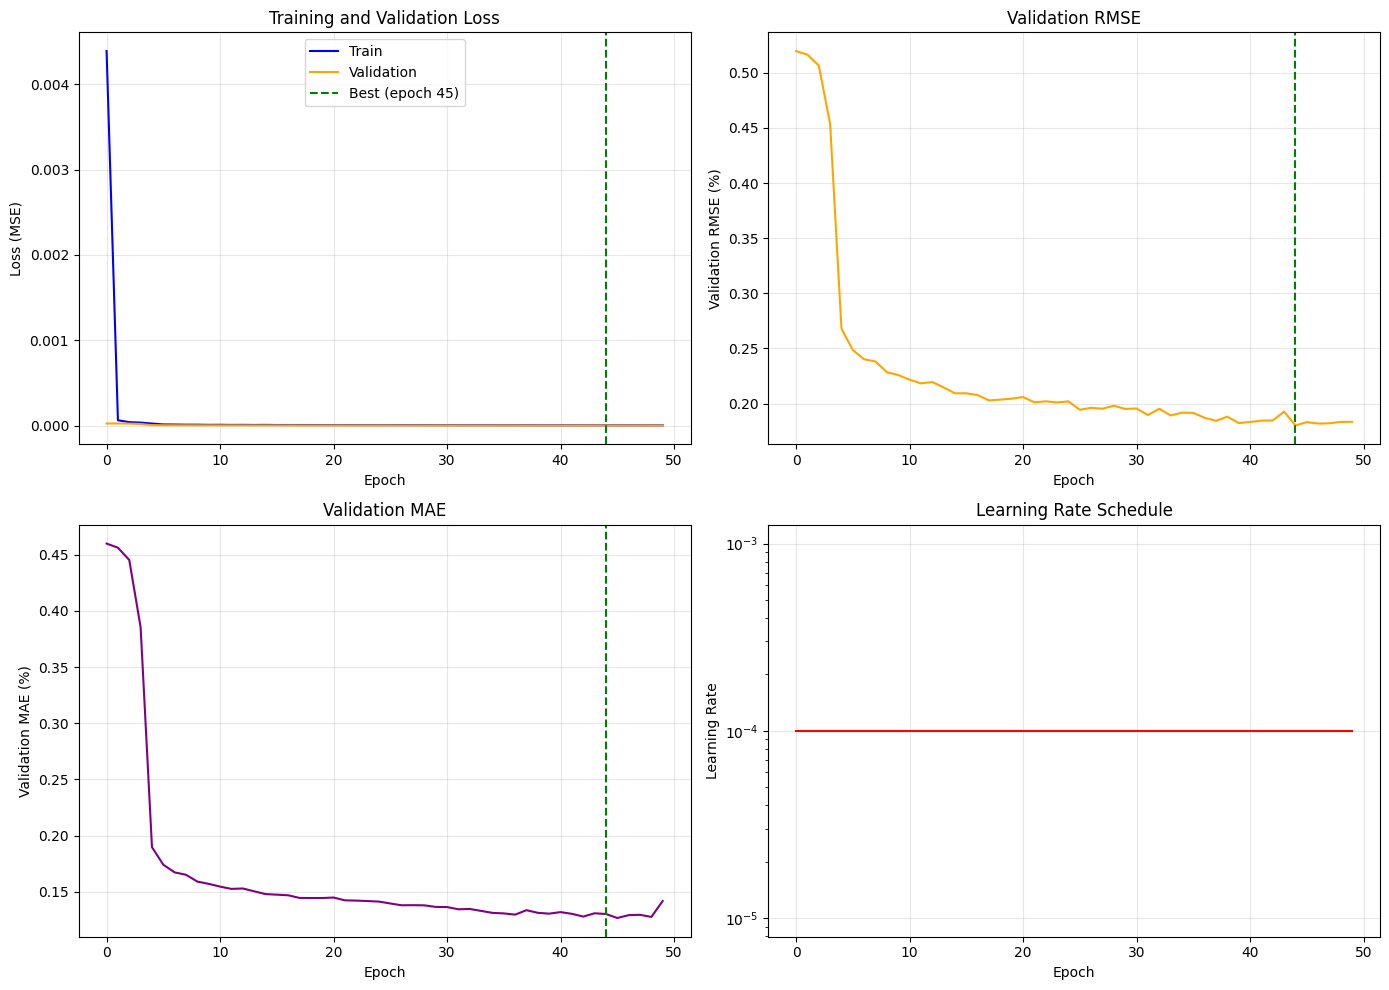

In [18]:
# =============================================================================
# STEP 5.2: Plot training history
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', color='blue')
axes[0, 0].plot(history['val_loss'], label='Validation', color='orange')
axes[0, 0].axvline(x=best_epoch, color='green', linestyle='--', label=f'Best (epoch {best_epoch+1})')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# RMSE
axes[0, 1].plot([r * 100 for r in history['val_rmse']], color='orange')
axes[0, 1].axvline(x=best_epoch, color='green', linestyle='--')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation RMSE (%)')
axes[0, 1].set_title('Validation RMSE')
axes[0, 1].grid(True, alpha=0.3)

# MAE
axes[1, 0].plot([m * 100 for m in history['val_mae']], color='purple')
axes[1, 0].axvline(x=best_epoch, color='green', linestyle='--')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation MAE (%)')
axes[1, 0].set_title('Validation MAE')
axes[1, 0].grid(True, alpha=0.3)

# Learning rate
axes[1, 1].plot(history['lr'], color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Baseline Comparisons

### 🎓 Teaching Moment: Why Baselines Matter

From your Week 3 experience: your SPY transformer underperformed EWMA!
This taught you that complex models don't always win.

We compare against:
1. **Naive**: Predict that tomorrow's volatility = today's volatility
2. **Historical Average**: Predict the long-term average volatility
3. **EWMA**: Exponentially weighted moving average (strong baseline!)

In [19]:
# =============================================================================
# STEP 6.1: Compute baselines on test set
# =============================================================================

# Get transformer predictions on test set
_, test_rmse, test_mae, transformer_preds, test_targets = evaluate(
    model, test_loader, criterion, device
)

print(f"Transformer on test set:")
print(f"  RMSE: {test_rmse * 100:.4f}%")
print(f"  MAE:  {test_mae * 100:.4f}%")

Transformer on test set:
  RMSE: 0.2089%
  MAE:  0.1610%


In [20]:
# =============================================================================
# STEP 6.2: Naive baseline (yesterday's volatility)
# =============================================================================

# 🎓 Teaching Moment: Naive Forecast
#
# The naive forecast assumes volatility doesn't change: vol_{t+1} = vol_t
# This is surprisingly hard to beat due to volatility persistence!

# Get the realized volatility column from test data (before shift)
# We need to align properly with test targets
test_df_aligned = test_df.iloc[SEQ_LEN-1:].copy()  # Align with sequences

# Naive prediction: use historical 24h vol as prediction
naive_preds = test_df_aligned['realized_vol_24h'].values[:len(test_targets)]

# Need to unnormalize since test_df features are normalized
# The target is NOT normalized in our setup
naive_rmse = np.sqrt(np.mean((naive_preds - test_targets) ** 2))
naive_mae = np.mean(np.abs(naive_preds - test_targets))

print(f"\nNaive Baseline (vol_t = vol_{{t-1}}):")
print(f"  RMSE: {naive_rmse * 100:.4f}%")
print(f"  MAE:  {naive_mae * 100:.4f}%")


Naive Baseline (vol_t = vol_{t-1}):
  RMSE: 74.9729%
  MAE:  64.4247%


In [21]:
# =============================================================================
# STEP 6.3: Historical average baseline
# =============================================================================

# 🎓 Teaching Moment: Historical Average
#
# Always predict the training set's average volatility.
# This is the simplest possible model.

hist_avg = train_df[TARGET_COL].mean()
hist_avg_preds = np.full_like(test_targets, hist_avg)

hist_avg_rmse = np.sqrt(np.mean((hist_avg_preds - test_targets) ** 2))
hist_avg_mae = np.mean(np.abs(hist_avg_preds - test_targets))

print(f"\nHistorical Average Baseline:")
print(f"  Average vol: {hist_avg * 100:.4f}%")
print(f"  RMSE: {hist_avg_rmse * 100:.4f}%")
print(f"  MAE:  {hist_avg_mae * 100:.4f}%")


Historical Average Baseline:
  Average vol: 0.5861%
  RMSE: 0.2675%
  MAE:  0.2296%


In [22]:
# =============================================================================
# STEP 6.4: EWMA baseline
# =============================================================================

# 🎓 Teaching Moment: EWMA (Exponentially Weighted Moving Average)
#
# EWMA gives more weight to recent observations:
#   σ²_t = λ * r²_{t-1} + (1-λ) * σ²_{t-1}
#
# This is the industry standard for volatility forecasting.
# It's a strong baseline that captured 0.52 R² on your SPY data!

def ewma_volatility(returns, span=24):
    """Compute EWMA volatility forecast."""
    # Calculate squared returns
    squared_returns = returns ** 2
    # EWMA of squared returns
    ewma_var = squared_returns.ewm(span=span, adjust=False).mean()
    # Convert to volatility (std)
    ewma_vol = np.sqrt(ewma_var)
    return ewma_vol

# Compute EWMA on test data
# We need the original (non-normalized) returns
# Load fresh test data for this
test_df_raw = pd.read_csv(f'{DATA_DIR}/btc_test.csv')

# Get normalized stats to unnormalize
log_return_mean = metadata['feature_stats']['log_return']['mean']
log_return_std = metadata['feature_stats']['log_return']['std']

# Unnormalize log returns
test_returns_unnorm = test_df_raw['log_return'] * log_return_std + log_return_mean

# Compute EWMA
ewma_vol = ewma_volatility(test_returns_unnorm, span=24)

# Align with test targets (account for sequence length)
ewma_preds = ewma_vol.values[SEQ_LEN-1:SEQ_LEN-1+len(test_targets)]

ewma_rmse = np.sqrt(np.mean((ewma_preds - test_targets) ** 2))
ewma_mae = np.mean(np.abs(ewma_preds - test_targets))

print(f"\nEWMA Baseline (span=24):")
print(f"  RMSE: {ewma_rmse * 100:.4f}%")
print(f"  MAE:  {ewma_mae * 100:.4f}%")


EWMA Baseline (span=24):
  RMSE: 0.2068%
  MAE:  0.1538%


In [23]:
# =============================================================================
# STEP 6.5: Summary comparison
# =============================================================================

print("=" * 60)
print("MODEL COMPARISON ON TEST SET")
print("=" * 60)
print(f"\n{'Model':<25} {'RMSE (%)':<12} {'MAE (%)':<12}")
print("-" * 50)
print(f"{'Historical Average':<25} {hist_avg_rmse*100:<12.4f} {hist_avg_mae*100:<12.4f}")
print(f"{'Naive (persistence)':<25} {naive_rmse*100:<12.4f} {naive_mae*100:<12.4f}")
print(f"{'EWMA (span=24)':<25} {ewma_rmse*100:<12.4f} {ewma_mae*100:<12.4f}")
print(f"{'Transformer':<25} {test_rmse*100:<12.4f} {test_mae*100:<12.4f}")
print("-" * 50)

# Relative improvement over EWMA
improvement = (ewma_rmse - test_rmse) / ewma_rmse * 100
print(f"\nTransformer vs EWMA: {improvement:+.2f}% RMSE change")
if improvement > 0:
    print("  → Transformer outperforms EWMA! 🎉")
else:
    print("  → EWMA still wins (this is common for volatility forecasting)")

MODEL COMPARISON ON TEST SET

Model                     RMSE (%)     MAE (%)     
--------------------------------------------------
Historical Average        0.2675       0.2296      
Naive (persistence)       74.9729      64.4247     
EWMA (span=24)            0.2068       0.1538      
Transformer               0.2089       0.1610      
--------------------------------------------------

Transformer vs EWMA: -1.03% RMSE change
  → EWMA still wins (this is common for volatility forecasting)


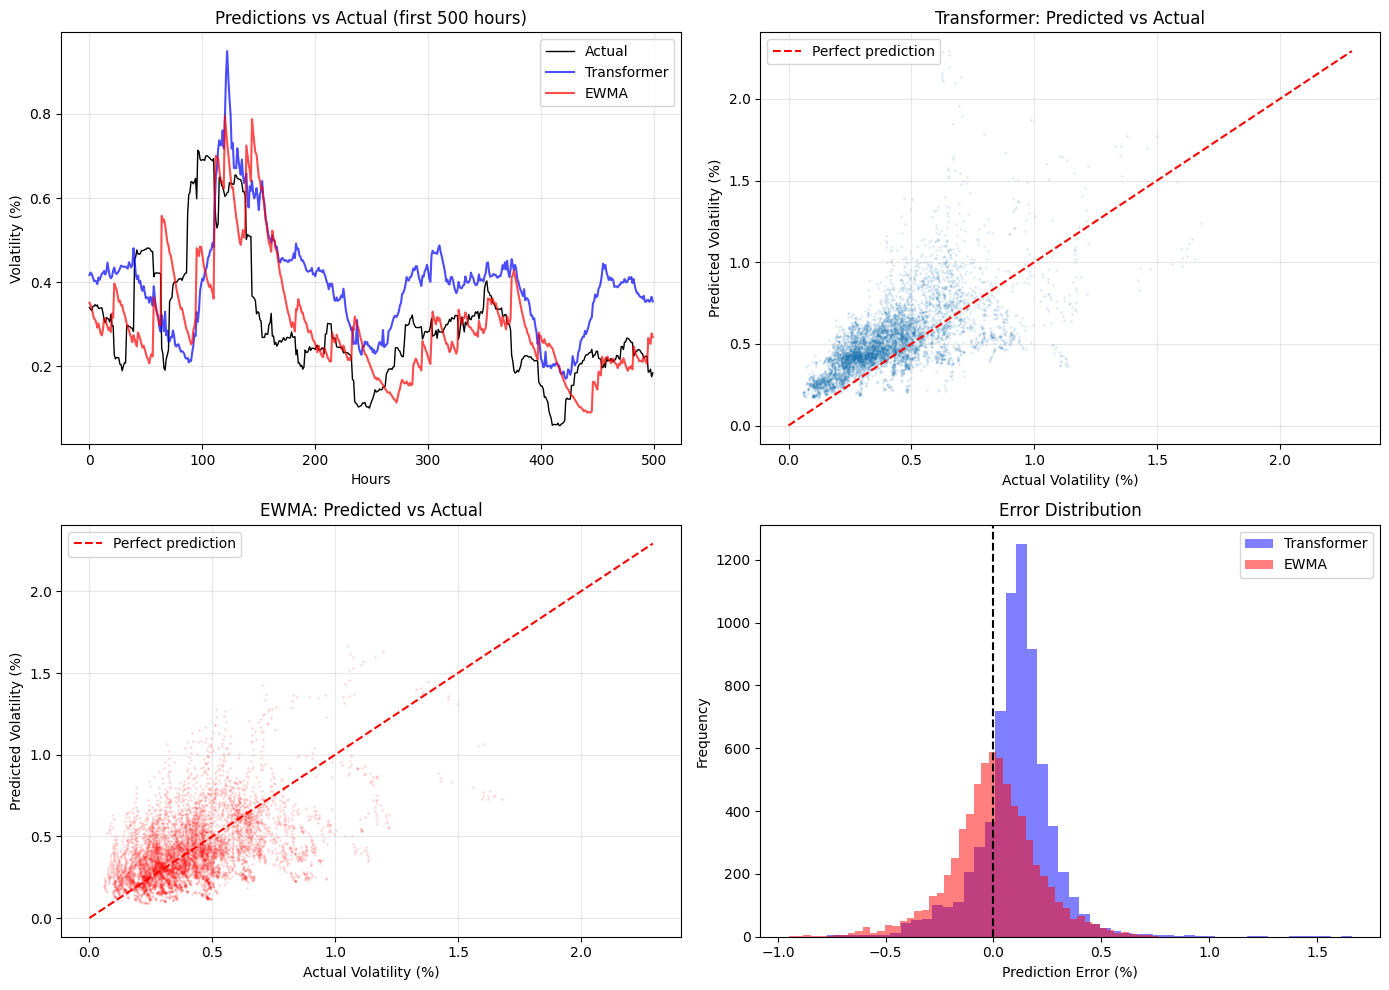

In [24]:
# =============================================================================
# STEP 6.6: Visualization of predictions
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subset for cleaner plotting
plot_len = min(500, len(test_targets))

# Time series comparison
ax = axes[0, 0]
ax.plot(test_targets[:plot_len] * 100, label='Actual', color='black', linewidth=1)
ax.plot(transformer_preds[:plot_len] * 100, label='Transformer', color='blue', alpha=0.7)
ax.plot(ewma_preds[:plot_len] * 100, label='EWMA', color='red', alpha=0.7)
ax.set_xlabel('Hours')
ax.set_ylabel('Volatility (%)')
ax.set_title('Predictions vs Actual (first 500 hours)')
ax.legend()
ax.grid(True, alpha=0.3)

# Scatter: Transformer
ax = axes[0, 1]
ax.scatter(test_targets * 100, transformer_preds * 100, alpha=0.1, s=1)
max_val = max(test_targets.max(), transformer_preds.max()) * 100
ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Volatility (%)')
ax.set_ylabel('Predicted Volatility (%)')
ax.set_title('Transformer: Predicted vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)

# Scatter: EWMA
ax = axes[1, 0]
ax.scatter(test_targets * 100, ewma_preds * 100, alpha=0.1, s=1, color='red')
ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Volatility (%)')
ax.set_ylabel('Predicted Volatility (%)')
ax.set_title('EWMA: Predicted vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)

# Error distribution
ax = axes[1, 1]
transformer_errors = (transformer_preds - test_targets) * 100
ewma_errors = (ewma_preds - test_targets) * 100
ax.hist(transformer_errors, bins=50, alpha=0.5, label='Transformer', color='blue')
ax.hist(ewma_errors, bins=50, alpha=0.5, label='EWMA', color='red')
ax.axvline(x=0, color='black', linestyle='--')
ax.set_xlabel('Prediction Error (%)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution')
ax.legend()

plt.tight_layout()
plt.show()

---
## Section 7: Mincer-Zarnowitz Regression

### 🎓 Teaching Moment: Forecast Evaluation

From your Week 3 work, you know the Mincer-Zarnowitz regression:

$$\text{actual}_t = \alpha + \beta \cdot \text{predicted}_t + \epsilon_t$$

For a well-calibrated forecast:
- α should be 0 (no systematic bias)
- β should be 1 (predictions scale correctly)
- R² measures explained variance

In [25]:
# =============================================================================
# STEP 7.1: Mincer-Zarnowitz regression
# =============================================================================

from scipy import stats

def mincer_zarnowitz(actuals, predictions, name):
    """Run Mincer-Zarnowitz regression."""
    slope, intercept, r_value, p_value, std_err = stats.linregress(predictions, actuals)
    r_squared = r_value ** 2

    print(f"{name}:")
    print(f"  α (intercept) = {intercept:.6f}  (ideal: 0)")
    print(f"  β (slope)     = {slope:.4f}       (ideal: 1)")
    print(f"  R²            = {r_squared:.4f}")
    print()

    return intercept, slope, r_squared

print("=" * 60)
print("MINCER-ZARNOWITZ REGRESSION RESULTS")
print("=" * 60)
print()

mz_transformer = mincer_zarnowitz(test_targets, transformer_preds, 'Transformer')
mz_naive = mincer_zarnowitz(test_targets, naive_preds, 'Naive')
mz_ewma = mincer_zarnowitz(test_targets, ewma_preds, 'EWMA')

MINCER-ZARNOWITZ REGRESSION RESULTS

Transformer:
  α (intercept) = 0.000997  (ideal: 0)
  β (slope)     = 0.6075       (ideal: 1)
  R²            = 0.4052

Naive:
  α (intercept) = 0.004940  (ideal: 0)
  β (slope)     = 0.0016       (ideal: 1)
  R²            = 0.2064

EWMA:
  α (intercept) = 0.002069  (ideal: 0)
  β (slope)     = 0.4997       (ideal: 1)
  R²            = 0.2357



---
## Section 8: Save Model

We save:
1. Model weights (for inference)
2. Model config (to reconstruct architecture)
3. Training history (for analysis)

In [26]:
# =============================================================================
# STEP 8.1: Save model and config
# =============================================================================

# Model config
model_config = {
    'num_features': NUM_FEATURES,
    'd_model': D_MODEL,
    'num_heads': NUM_HEADS,
    'num_layers': NUM_LAYERS,
    'd_ff': D_FF,
    'dropout': DROPOUT,
    'seq_len': SEQ_LEN,
    'feature_columns': FEATURE_COLS,
    'target_column': TARGET_COL
}

# Save to Google Drive
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': model_config,
    'history': history,
    'best_epoch': best_epoch,
    'test_metrics': {
        'rmse': test_rmse,
        'mae': test_mae
    }
}, f'{DATA_DIR}/volatility_transformer.pt')

print(f"✓ Model saved to {DATA_DIR}/volatility_transformer.pt")

✓ Model saved to /content/drive/MyDrive/btc_volatility_project/volatility_transformer.pt


In [27]:
# =============================================================================
# STEP 8.2: Demonstrate loading the model
# =============================================================================

# 🎓 Teaching Moment: Loading Saved Models
#
# To use the model later (e.g., in Part 3 for trading or Part 4 for MCP agent):

# Load checkpoint
checkpoint = torch.load(f'{DATA_DIR}/volatility_transformer.pt', weights_only=False)

# Recreate model with saved config
loaded_config = checkpoint['model_config']
loaded_model = VolatilityTransformer(
    num_features=loaded_config['num_features'],
    d_model=loaded_config['d_model'],
    num_heads=loaded_config['num_heads'],
    num_layers=loaded_config['num_layers'],
    d_ff=loaded_config['d_ff'],
    dropout=loaded_config['dropout']
).to(device)

# Load weights
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print("✓ Model loaded successfully!")
print(f"  Best epoch: {checkpoint['best_epoch'] + 1}")
print(f"  Test RMSE:  {checkpoint['test_metrics']['rmse']*100:.4f}%")

✓ Model loaded successfully!
  Best epoch: 45
  Test RMSE:  0.2089%


---
## Section 9: Summary and Next Steps

In [28]:
# =============================================================================
# Final Summary
# =============================================================================

print("=" * 60)
print("BTC VOLATILITY TRANSFORMER - TRAINING SUMMARY")
print("=" * 60)

print(f"\n📊 Data:")
print(f"   Sequence length: {SEQ_LEN} hours ({SEQ_LEN/24:.1f} days)")
print(f"   Training sequences: {len(train_dataset):,}")
print(f"   Features: {NUM_FEATURES}")

print(f"\n🏗️ Model:")
print(f"   Architecture: Transformer (d={D_MODEL}, h={NUM_HEADS}, L={NUM_LAYERS})")
print(f"   Parameters: {num_params:,}")
print(f"   Best epoch: {best_epoch + 1}")

print(f"\n📈 Performance (Test Set):")
print(f"   Transformer RMSE: {test_rmse*100:.4f}%")
print(f"   EWMA RMSE:        {ewma_rmse*100:.4f}%")
print(f"   Improvement:      {(ewma_rmse-test_rmse)/ewma_rmse*100:+.2f}%")

print(f"\n📁 Saved Files:")
print(f"   {DATA_DIR}/volatility_transformer.pt")

print(f"\n🚀 Next Steps:")
print(f"   Part 3: Build trading strategy using predictions")
print(f"   Part 4: Wrap as MCP agent (Week 4 capstone)")

BTC VOLATILITY TRANSFORMER - TRAINING SUMMARY

📊 Data:
   Sequence length: 64 hours (2.7 days)
   Training sequences: 31,927
   Features: 16

🏗️ Model:
   Architecture: Transformer (d=128, h=4, L=4)
   Parameters: 795,649
   Best epoch: 45

📈 Performance (Test Set):
   Transformer RMSE: 0.2089%
   EWMA RMSE:        0.2068%
   Improvement:      -1.03%

📁 Saved Files:
   /content/drive/MyDrive/btc_volatility_project/volatility_transformer.pt

🚀 Next Steps:
   Part 3: Build trading strategy using predictions
   Part 4: Wrap as MCP agent (Week 4 capstone)


---
## 🎓 Key Learnings from This Notebook

1. **Sequence Datasets**: How to create overlapping windows for time series

2. **Architecture Adaptation**: Same transformer blocks, different input/output layers
   - `nn.Linear` instead of `nn.Embedding` for continuous features
   - Single regression output instead of softmax classification

3. **Training Best Practices**:
   - Early stopping to prevent overfitting
   - Learning rate scheduling
   - Gradient clipping

4. **Baseline Comparison**: Always compare against simple models!
   - EWMA is a strong baseline for volatility

5. **Mincer-Zarnowitz**: Standard test for forecast calibration

---

**Questions to think about before Part 3:**
- How would you convert volatility predictions into trading signals?
- Should you trade when predicted volatility is high or low?
- How do spreads affect strategy profitability?